# 5장 2강: 부스팅 계열 모델의 원리와 발전

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 부스팅 계열 모델의 순차 학습 원리와 주요 모델의 차이를 확인합니다.

- AdaBoost와 Gradient Boosting의 순차 학습 원리를 이해합니다.
- Gradient Boosting이 이전 모델의 잔차를 보완하는 흐름을 확인합니다.
- XGBoost와 LightGBM을 같은 데이터에서 비교합니다.
- `learning_rate`, `n_estimators`, `max_depth`의 역할을 확인합니다.
- Early Stopping의 목적을 이해합니다.
- 부스팅이 단계적으로 편향을 줄여가는 이유를 설명합니다.

> 이 실습에서는 5장 2강 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- lightgbm
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. 같은 데이터에서 Gradient Boosting, XGBoost, LightGBM을 비교합니다.

In [1]:
pip install lightbm scikit-learn

Note: you may need to restart the kernel to use updated packages.


c:\ml2\.venv\Scripts\python.exe: No module named pip


In [2]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 부스팅의 순차 학습 원리 확인

## 문제 1. AdaBoost와 Gradient Boosting의 차이를 정리하세요.

### 요구사항

다음 두 모델이 이전 모델의 실수를 어떻게 보완하는지 각각 작성합니다.

- AdaBoost
- Gradient Boosting

### 확인 포인트

- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는가?
- Gradient Boosting은 이전 모델의 잔차를 다음 모델이 학습하는가?

### Q1. AdaBoost와 Gradient Boosting은 각각 무엇에 집중하여 다음 모델을 학습하나요?

**답변:**  
- AdaBoost는 이전 모델이 틀린 샘플에 더 높은 가중치를 부여하여 그 샘플에 더 집중해서 학습하는 방식
- Gradient Boosting은 이전 모델이 남긴 오차를 다음 모델이 학습하도록 하는 방식

## 문제 2. Gradient Boosting의 단계별 성능 변화를 확인하세요.

### 요구사항

1. `GradientBoostingRegressor`를 사용합니다.
2. `n_estimators=100`
3. `learning_rate=0.05`
4. `max_depth=2`
5. `random_state=42`
6. 모델을 학습합니다.
7. `staged_predict()`를 사용해 나무가 추가될 때마다 Test RMSE를 계산합니다.
8. 나무 개수에 따른 Test RMSE를 선 그래프로 나타냅니다.

### 확인 포인트

- 순차적으로 나무가 추가되면서 예측 오차가 감소하는 구간을 확인했는가?
- 이전까지 설명하지 못한 부분을 다음 나무가 보완한다는 개념과 연결할 수 있는가?

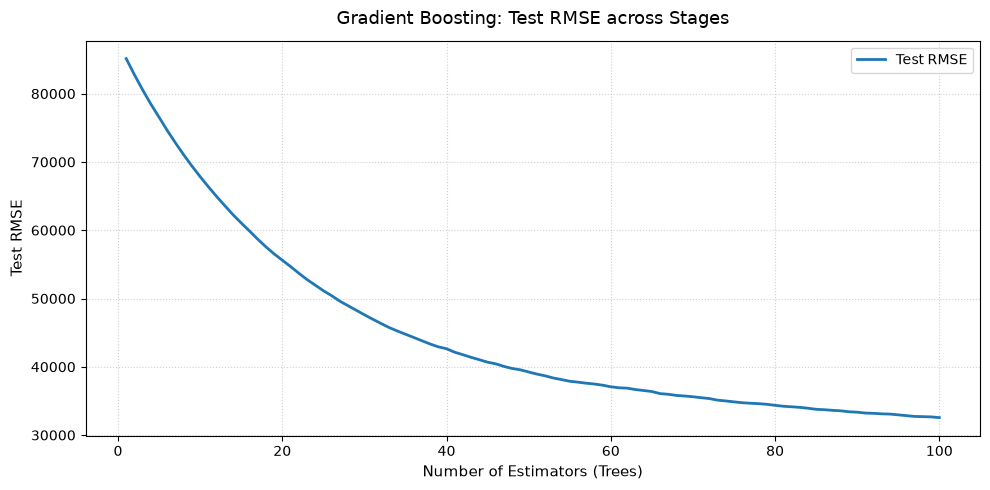

1번째 나무 추가 후 Test RMSE  : 85,132.58
100번째 나무 추가 후 Test RMSE: 32,559.19


In [3]:
# TODO
# GradientBoostingRegressor를 학습하고
# staged_predict()를 이용해 단계별 Test RMSE를 확인하세요.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# 1~5. GradientBoostingRegressor 모델 생성
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

# 6. 모델 학습
gbr.fit(X_train, y_train)

# 7. staged_predict()를 사용해 나무가 추가될 때마다 Test RMSE 계산
stage_rmse_list = []

for y_stage_pred in gbr.staged_predict(X_test):
    stage_rmse = np.sqrt(mean_squared_error(y_test, y_stage_pred))
    stage_rmse_list.append(stage_rmse)

# 8. 나무 개수(1 ~ 100)에 따른 Test RMSE 선 그래프 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(stage_rmse_list) + 1), stage_rmse_list, color="tab:blue", linewidth=2, label="Test RMSE")
plt.title("Gradient Boosting: Test RMSE across Stages", fontsize=13, pad=12)
plt.xlabel("Number of Estimators (Trees)", fontsize=11)
plt.ylabel("Test RMSE", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 시작점과 최종 지점 오차 비교
print(f"1번째 나무 추가 후 Test RMSE  : {stage_rmse_list[0]:,.2f}")

print(f"100번째 나무 추가 후 Test RMSE: {stage_rmse_list[-1]:,.2f}")

#### n_estimators=100의 의미
- 최대 100개의 순차적으로 보정을 하는 나무를 추가한다.
#### learning_rate=0.05의 의미
- 세 나무의 보정값을 0.05배하여 현재 예측에 더하겠다.
#### max_depth=2의 의미
- 개별 나무의 깊이를 최대 2개로 제한한다.
####
- Train에서 남은 오차를 다음 나무가 학습한다.
- 잔차를 지속적으로 줄여나가는 모델
###
- RMSE: 예측오차를 제곱하여 평균을 낸 뒤 제곱근을 취한다 -> 작을수록 좋은 값 (Error->Square->Mean->Root)
- 완벽한 예측은 0에 수렴한다. 오차가 제곱이 되어 더 크게 반영되므로, 큰 오차를 더욱 민감하게 탐지해낼 수 있다.
- 판매 가격이 달러라면 RMSE도 달러로 해석할 수 있다.(원본 데이터와 같은 단위로 비교 가능)
#### 나무가 많아질수록 Test의 오차는 무조건 내려가는가?
- 아니오. 학습은 Train의 손실을 줄이는 방향으로 진행되며, Test의 정답으로 보정 나무를 학습하지는 않음
- Train의 나무를 계속 추가하면 Train의 노이즈까지 학습하여 성능 결과가 좋지 않을 수 있음.
#### staged_predict와 Early Stopping
- staged_predict: 100단계까지 학습한 뒤 Test 예측을 관찰하는 것, 중간에 가장 좋은(손실이 적은) 학습 단계가 있어도 100번을 채울때까지 멈추지 않음
- Early Stopping : n번만큼 학습했을 때 손실이 더 이상 줄어들지 않는 지점을 찾아서 모델을 종료

#### Q2. 부스팅에서 나무를 순차적으로 추가하는 이유는 무엇인가요?

**답변:**  
- 이전 나무의 오차를 다음 나무가 이어받아 순차적으로 교정하기 위해서.
- 아직 설명이 충분히 되지 않은 패턴을 계속 보완하려고 함

---

# 필수 2. XGBoost와 LightGBM 비교

## 문제 1. 두 모델을 같은 조건에서 학습하세요.

### 요구사항

다음 공통 설정을 사용합니다.

- `n_estimators=200`
- `learning_rate=0.05`
- `max_depth=3`
- `random_state=42`

다음 두 모델을 학습합니다.

- `XGBRegressor`
- `LGBMRegressor`

각 모델에 대해 다음을 확인합니다.

1. 학습 시간
2. Test RMSE

### 확인 포인트

- XGBoost와 LightGBM을 같은 데이터와 같은 주요 하이퍼파라미터 조건에서 비교했는가?
- LightGBM이 빠른 학습을 강점으로 갖는다는 교안 내용과 연결할 수 있는가?

In [4]:
# TODO
# XGBoost와 LightGBM의 학습 시간과 Test RMSE를 비교하세요.
import time
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# 1. 모델 정의 (동일 하이퍼파라미터 조건 부여)
# n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

lgbm = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # 불필요한 경고 메시지 억제
)

results = []

# 2. XGBoost 학습 시간 및 Test RMSE 측정
start_time_xgb = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start_time_xgb

y_pred_xgb = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

results.append({
    "모델": "XGBoost",
    "학습 시간 (초)": xgb_train_time,
    "Test RMSE": xgb_rmse
})

# 3. LightGBM 학습 시간 및 Test RMSE 측정
start_time_lgbm = time.time()
lgbm.fit(X_train, y_train)
lgbm_train_time = time.time() - start_time_lgbm

y_pred_lgbm = lgbm.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

results.append({
    "모델": "LightGBM",
    "학습 시간 (초)": lgbm_train_time,
    "Test RMSE": lgbm_rmse
})

# 4. 결과 DataFrame 정리 및 출력
comparison_df = pd.DataFrame(results)

print("=== XGBoost vs LightGBM 성능 및 속도 비교 ===")
display(
    comparison_df.style.format({
        "학습 시간 (초)": "{:.4f}초",
        "Test RMSE": "{:,.2f}"
    })
)

=== XGBoost vs LightGBM 성능 및 속도 비교 ===


,모델,학습 시간 (초),Test RMSE
0,XGBoost,0.1599초,"28,405.32"
1,LightGBM,0.0319초,"31,813.09"


#### Depth-wise :뿌리에 가까운 깊이의 노드를 우선 확장 (XGBoost)
- 같은 깊이의 노드를 균등하게 확장하려고 함
#### Leaf-wise : 현재 잎들 중 손실을 가장 많이 줄일 분할을 우선 확장 (LightGBM)
- 손실 감소가 많았던 친구부터 확장하려고 함
- XGBoost는 기본적으로 Depth-wise 성장을 따르고 LightGBM은 Leaf-wise 성장을 따른다.
###
- 현재 지표로만 대표적인 모델을 설정하는 것은 무리이므로 다른 성능평가지표도 함께 체크해야함
- 현재 지표로만 대표적인 모델을 설정해본다면 RMSE(오차 제곱근)과 시간 효율성이 좋은 XGBoost를 선택한다.


#### Q3. XGBoost와 LightGBM의 기본 트리 성장 방식 차이는 무엇인가요?

**답변:**  
- XGBoost는 기본적으로 Depth-wise 성장을 따르고 LightGBM은 Leaf-wise 성장을 따른다.

#### Q4. CatBoost의 구조적 특징과 강점은 무엇인가요?

**답변:** Symmetric Tree 구조 사용, 같은 깊이의 노드에 같은 분할 조건을 적용
- 범주형 데이터 처리에 가장 강한 강점이 있음

## 문제 2. learning_rate와 n_estimators의 관계를 확인하세요.

### 요구사항

다음 조합을 비교합니다.

```python
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]
```

각 조합에 대해 `GradientBoostingRegressor(max_depth=2, random_state=42)`를 학습하고 다음을 확인합니다.

1. Test RMSE
2. 학습 시간

### 확인 포인트

- learning_rate가 작을수록 더 많은 나무가 필요할 수 있음을 확인했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [5]:
# TODO
# learning_rate / n_estimators 조합별 Test RMSE와 학습 시간을 비교하세요.
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300},
]

comparison_list = []

for config in settings:
    lr = config["learning_rate"]
    n_est = config["n_estimators"]

    # 모델 초기화
    gbr_model = GradientBoostingRegressor(
        learning_rate=lr,
        n_estimators=n_est,
        max_depth=2,
        random_state=42
    )

    # 1. 학습 시간 측정
    start_time = time.time()
    gbr_model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    # 2. Test RMSE 계산
    y_pred = gbr_model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    comparison_list.append({
        "learning_rate": lr,
        "n_estimators": n_est,
        "Test RMSE": test_rmse,
        "학습 시간 (초)": elapsed_time
    })

# 결과 출력
results_df = pd.DataFrame(comparison_list)
print("=== learning_rate / n_estimators 조합별 비교 결과 ===")
display(
    results_df.style.format({
        "learning_rate": "{:.2f}",
        "n_estimators": "{}",
        "Test RMSE": "{:,.2f}",
        "학습 시간 (초)": "{:.4f}초"
    })
)

=== learning_rate / n_estimators 조합별 비교 결과 ===


,learning_rate,n_estimators,Test RMSE,학습 시간 (초)
0,0.10,50,"31,791.28",0.0464초
1,0.05,100,"32,559.19",0.0816초
2,0.01,300,"37,165.99",0.2473초


#### learning_rate=0.05의 의미
- 새 나무가 출력할 보정값을 0.05배하여 더한다는 뜻

#### 작은 학습률에서 더 많은 나무가 필요한 경우가 있는가?
- learning_rate가 작으면 유용한 패턴을 누적하여 학습하는데에 오랜 시간과 단계가 필요할 수 있다.
- 작은 학습률은 점진적인 학습을 가능하게 하지만, 주어진 나무의 수가 적다면 보정이 덜 된 상태로 학습이 끝날 가능성이 있다.


#### Q5. learning_rate를 작게 만들면 왜 n_estimators를 함께 늘려야 할 수 있나요?

**답변:**  
- 각 나무가 최종 예측에 반영되는 비율이 작기 때문에 같은 정도의 오차 보완을 위해 더 많은 단계가 필요할 수 있다.

#### Early Stopping을 사용하는 이유
- 학습을 멈출 수 있는 장치인 Early Stopping이 없다면 최적의 RMSE를 보여도 모델은 멈추지 않고 학습할 수 있다.
- Early Stopping은 가장 좋은 단계의 나무 수를 통해 Loss 갱신이 없으면 학습을 강제로 종료하여 최적의 성능과 시간적 효율을 높일 수 있다.

---

# 과제 1. Early Stopping과 부스팅 모델 선택

## 배경

교안에서는 `n_estimators`를 충분히 크게 설정하고, 검증 성능이 더 이상 좋아지지 않으면 학습을 멈추는 **Early Stopping**을 소개했습니다.

이번 과제에서는 XGBoost에서 이 흐름을 적용합니다.

> 과제는 필수 실습에서 사용한 모델과 하이퍼파라미터를 그대로 활용하는 수준입니다.

## 요구사항

1. Train 데이터를 다시 Train / Validation으로 나눕니다.
2. `XGBRegressor`를 사용합니다.
3. `n_estimators=1000`
4. `learning_rate=0.05`
5. `max_depth=3`
6. `early_stopping_rounds=20`
7. Train 데이터로 학습하고 Validation 데이터를 `eval_set`으로 전달합니다.
8. Test 데이터의 RMSE를 계산합니다.
9. 실제로 사용된 나무 수를 확인합니다.
10. `n_estimators=1000`을 모두 사용하지 않고 중간에 멈췄다면 그 이유를 설명합니다.

11. Q7에서 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산, 과적합에 미치는 영향을 비교합니다. 새로운 모델 학습 코드는 요구하지 않습니다.

### 확인 포인트

- Early Stopping이 Validation 성능을 기준으로 동작한다는 점을 이해했는가?
- 불필요하게 많은 나무를 쌓는 것을 막는 목적을 설명할 수 있는가?
- 과적합 방지와 학습 시간 절약이라는 두 가지 의미를 설명할 수 있는가?
- 배깅의 부트스트랩·예측 결합, 랜덤포레스트의 특성 무작위 선택, 부스팅의 순차적 오류 보완을 설명할 수 있는가?
- 각 방식이 편향·분산에 미치는 일반적인 영향과 과적합 가능성을 구분할 수 있는가?


In [7]:
# TODO
# XGBoost에 Early Stopping을 적용하세요.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# 1. Train 데이터를 다시 Train(80%) / Validation(20%)으로 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

# 2~6. Early Stopping 설정이 포함된 XGBRegressor 생성
xgb_early = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

# 7. Train 학습 및 Validation 세트를 eval_set으로 전달하여 검증 점수 모니터링
xgb_early.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False  # 불필요한 라운드별 로그 억제
)

# 8. Test 데이터 예측 및 RMSE 계산
y_pred_test = xgb_early.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

# 9. 최적 반복 횟수(실제 사용된 트리 수) 확인
best_iteration = xgb_early.best_iteration
actual_trees = best_iteration + 1  # 인덱스 기준이므로 +1

print("=== XGBoost Early Stopping 적용 결과 ===")
print(f"설정된 최대 트리 수 (n_estimators) : 1,000")
print(f"최적 반복 라운드 (best_iteration)       : {best_iteration}회")
print(f"실제 사용된 최적 트리 수               : {actual_trees}개")
print(f"Hold-out Test RMSE                    : {test_rmse:,.2f}")

=== XGBoost Early Stopping 적용 결과 ===
설정된 최대 트리 수 (n_estimators) : 1,000
최적 반복 라운드 (best_iteration)       : 107회
실제 사용된 최적 트리 수               : 108개
Hold-out Test RMSE                    : 30,332.88


### Q6. Early Stopping은 어떤 상황에서 학습을 멈추나요?

**답변:**  
- 위 모델의 경우 Loss가 20회 동안 줄어들지 않으면 최적화 된 것으로 보고 학습을 멈춘다.

#### Q7. 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산에 미치는 영향을 비교하세요.

다음 항목을 포함하여 각 방법을 설명하세요.

1. **배깅:** 부트스트랩 표본을 만드는 방법과 여러 모델의 예측을 결합하는 방법, 분산 감소의 이유
2. **랜덤포레스트:** 배깅에 더해 각 노드의 분할 후보 특성을 무작위로 선택하는 이유와 트리 간 상관·분산에 미치는 영향
3. **부스팅:** 이전 모델의 오류를 순차적으로 보완하는 원리와 편향 감소의 관계, 과적합 가능성 및 이를 줄이는 방법

> 편향·분산에 대한 효과는 일반적인 경향입니다. 한 방법이 편향 또는 분산만 바꾸거나 과적합을 항상 막는다고 단정하지 마세요.

**답변:**
#### 배깅: 
- 복원추출을 통해 크기가 동일한 여러개의 서로 다른 표본을 생성하여 독립적인 트리들을 병렬 학습한 뒤 예측치를 평균 또는 투표하여 결합한다. 
- 각 트리의 예측 결과를 평균 내는 과정에서 넓게 분산되어있던 예측치가 어느정도 모아지므로 편향은 어느정도 유지되면서도 분산이 감소한다. 
#### 랜덤포레스트:
- 배깅의 원리를 기본으로 하나, feature importance가 높은 특성이 모든 트리의 상위 노드에 들어가는 것을 막아 트리 간의 상관계수를 낮추어 분산 감소 효과가 크게 증가한다.
#### 부스팅:
- 모델들이 이전 모델의 오류를 학습하고 순차적으로 보완하여 왜 틀렸는지에 대해서 학습하므로, 다른 가능성을 고려하는 과정에서 편향이 감소한다.
- 그러나 과도하게 깊은 학습을 할 경우 너무 많은 선택지를 고려하여 분산이 커지고 과적합 위험이 높아진다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 부스팅은 여러 모델을 병렬로 학습하나요, 순차적으로 학습하나요?
- 순차
2. AdaBoost는 이전 모델이 틀린 샘플을 어떻게 처리하나요?
- 이전 모델이 틀린 샘플의 가중치를 높인다.
3. Gradient Boosting은 다음 모델이 무엇을 학습하나요?
- 이전 모델이 남긴 잔차를 다음 모델이 학습한다.
4. XGBoost와 LightGBM의 기본 트리 성장 방식은 어떻게 다른가요?
- XGBoost는 Depth-wise
- LightGBM은 Leaf-wise
5. `learning_rate`와 `n_estimators`는 어떤 관계가 있나요?
- learning_rate가 작을수록 일반적으로 더 많은 나무가 필요할 수 있다.
6. Early Stopping을 사용하는 이유는 무엇인가요?
- Validation 성능이 더 이상 좋아지지 않을 때(학습 손실Loss이 더 이상 줄어들지 않을 때) 학습을 멈춰서 과적합과 불필요한 학습을 줄인다.
7. 부스팅은 편향과 분산 중 어떤 문제를 줄이는 데 특히 초점을 두나요?
- 편향. 단계적으로 이전 오차를 보완하면서 편향을 줄이는 데 초점을 둔다.